#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from pathlib import Path
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *
from bayesian_forward_simulator import BayesianForwardSimulator
from portfolio_optimizer_inputs import PortfolioOptimizerInputs
from portfolio_optimizer import PortfolioOptimizer

--- 
## Asset and Fitting Date Choices

#### -------------------------------------------------------------------------------------------------

In [2]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

# print('Commodities:', commodity_close_prices.columns.tolist())
# print('ETFs:', etf_close_prices.columns.tolist())
# print('Universe:', universe_close_prices.columns.tolist())

In [3]:
etf_always_disclude = ['Vanguard S&P 500 ETF', 'Real Estate Select Sector SPDR', 'Communication Services Select Sector SPDR']
etf_disclude = [name for name in etf_data.columns if 'Russell 1000' in name or 'Russell 3000' in name]\
                        + ['S&P 500', 'Nasdaq Composite', 'Dow Jones Industrial Average', 'Nasdaq 100', 'Russell 2000']

etf_include = list(set(etf_close_prices.columns.tolist()) - set(etf_always_disclude) - set(etf_disclude))
etf_close_prices = etf_close_prices[etf_include]

us_treasury = ['SPDR Bloomberg 1-3 Month T-Bill ETF', 'iShares 1-3 Year Treasury Bond ETF', 'iShares 7-10 Year Treasury Bond ETF']
int_equity = ['Vanguard Total International Stock ETF', 'Vanguard FTSE Developed Markets ETF',\
                                        'Vanguard FTSE Emerging Markets ETF','Vanguard FTSE Europe ETF',\
                                        'Vanguard FTSE Pacific ETF', 'iShares China Large-Cap ETF',\
                                        'iShares MSCI Japan ETF', 'iShares MSCI India ETF']
us_equity = list(set(etf_include) - set(us_treasury) - set(int_equity))
# print('US Equity:', us_equity)
# print('US Bond:', us_treasury)
# print('US Traded International Equity ETFs:', int_equity)

#### -------------------------------------------------------------------------------------------------

In [4]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,universe,us_equity,commodity,int_equity
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


In [5]:
rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
rebal_dates[:12]

['20181231',
 '20190131',
 '20190304',
 '20190402',
 '20190502',
 '20190603',
 '20190702',
 '20190801',
 '20190830',
 '20191001',
 '20191030',
 '20191129']

In [6]:
def load_models(asset_class: str, asset_name: str, end_date: str = '20181231') -> Tuple[KAMA_MSR, KMRF]:
    def _get_kama_msr_path(asset_class:str, asset_name: str, end_date: str) -> Path:
        filename = f"{asset_name}_KAMA-MSR_4-regimes.pkl"
        return Path('saved_models') / 'KAMA_MSR' / asset_class / end_date / filename

    def _get_kmrf_path(asset_class:str, asset_name: str) -> Path:
        filename = f"{asset_name}_KMRF_model.pkl"
        return Path('saved_models') / 'KMRF_new' / 'original' / asset_class / filename

    kama_msr_path = _get_kama_msr_path(asset_class, asset_name, end_date)
    kmrf_path = _get_kmrf_path(asset_class, asset_name)
    
    # Check if files exist
    if not kama_msr_path.exists():
        raise FileNotFoundError(
            f"KAMA+MSR model not found for {asset_name}: {kama_msr_path}"
        )
    if not kmrf_path.exists():
        raise FileNotFoundError(
            f"KMRF model not found for {asset_name}: {kmrf_path}"
        )
    
    # Load KAMA+MSR
    with open(kama_msr_path, 'rb') as f:
        kama_msr = pickle.load(f)
    
    # Load KMRF (suppress output)
    with contextlib.redirect_stdout(io.StringIO()):
        kmrf = KMRF.load_model(str(kmrf_path))
    
    return kama_msr, kmrf


#### -------------------------------------------------------------------------------------------------

In [7]:
DATE = rebal_dates[0] # 20181231
ASSET_CLASS = 'us_equity' # only used for BayesianForwardSimulator part
ASSET_NAME = 'SPDR S&P 500 ETF'

---

## Using the BayesianForwardSimulator Class


In [8]:
print(asset_names_df[ASSET_CLASS].iloc[0])
kama_msr, kmrf = load_models(ASSET_CLASS, 
                             ASSET_NAME,
                             DATE)

SPDR S&P 500 ETF



BAYESIAN FORWARD SIMULATION - FULL ANALYSIS

[1/5] Computing forward regime probabilities...
✓ Computed 21-day forward probabilities

[2/5] Fitting regime-specific distributions...

FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:
  N=4548, μ=0.00047, σ=0.00843
  skew=-0.345 (p=0.0000)***
  kurt=1.536 (p=0.0000)***
  → Normal Inverse Gaussian (both skew and kurt significant)
     MLE converged: a=1.1804, b=-0.1513, loc=0.00165, scale=0.00913

Regime 1:
  N=1128, μ=0.00049, σ=0.01277
  skew=0.059 (p=0.4175)
  kurt=0.074 (p=0.6106)
  → Normal distribution

Regime 2:
  N=44, μ=-0.00887, σ=0.03265
  skew=0.161 (p=0.5090)
  kurt=-0.389 (p=0.3220)
  → Normal distribution

Regime 3:
  N=303, μ=-0.00215, σ=0.03115
  skew=0.266 (p=0.0586)
  kurt=1.332 (p=0.0000)***
  → Student-t: df=8.50


[3/5] Validating distribution parameters...

DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale       df      a         b  n_obs
      0 norminvgauss   Tru

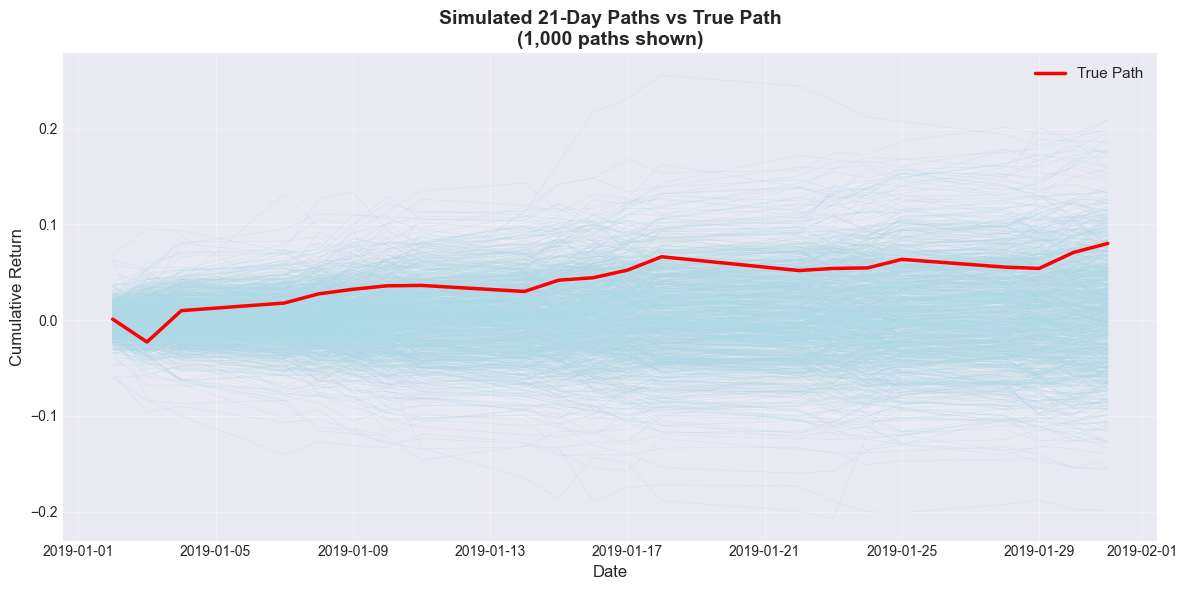

Generating terminal distribution...


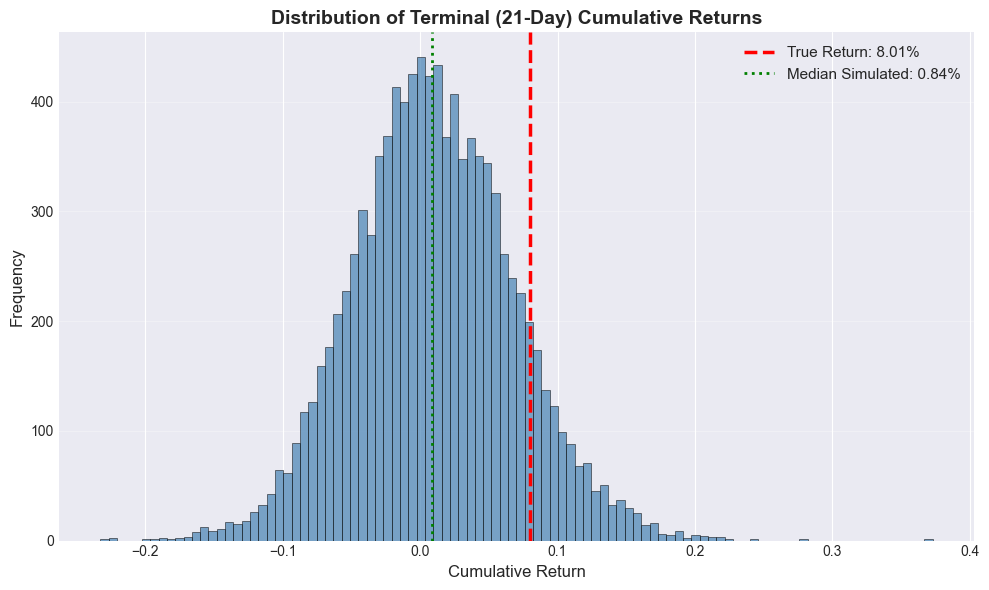


ANALYSIS COMPLETE


In [9]:
# Create simulator instance
simulator = BayesianForwardSimulator(
    kama_msr=kama_msr,
    kmrf=kmrf,
    n_days=21,
    alpha_confidence=0.75,
    significance_level=0.05
)

# Run full analysis pipeline
sim_results = simulator.run_full_analysis(
    n_simulations=10000,
    random_seed=1010,
    plot_paths=True,
    plot_terminal=True,
    n_paths_to_plot=1000
)

In [10]:
print(sim_results.keys())
sim_results['summary_stats']

dict_keys(['forward_probs', 'regime_distributions', 'validation', 'simulated_returns', 'summary_stats'])


count                 10000.000000
mean                      0.009911
std                       0.058479
min                      -0.232818
25%                      -0.028970
50%                       0.008368
75%                       0.048129
max                       0.373023
true_return               0.080066
percentile_of_true       88.780000
Name: Day t+21, dtype: float64

---

## Portfolio Optimization Inputs Generator

The `PortfolioOptimizerInputs` class generates μ and Σ for multiple assets using regime-conditional Bayesian simulations.

#### Example: Quick Run for Portfolio

In [11]:
asset_names_df[ASSET_CLASS][4:13]

4                     Energy Select Sector SPDR
5                  Financial Select Sector SPDR
6                  Utilities Select Sector SPDR
7                 Industrial Select Sector SPDR
8                Health Care Select Sector SPDR
9                 Technology Select Sector SPDR
10                 Materials Select Sector SPDR
11    Consumer Discretionary Select Sector SPDR
12          Consumer Staples Select Sector SPDR
Name: us_equity, dtype: object

In [12]:
# Compare daily, 21-day, and annualized returns
print("="*80)
print("RETURN COMPARISON: DAILY vs 21-DAY vs ANNUALIZED")
print("="*80)

portfolio_assets = asset_names_df[ASSET_CLASS][4:13].to_list()

# Run simulation once to get base results
ANNUALIZE = True
results = PortfolioOptimizerInputs.quick_run(
    asset_names=portfolio_assets,
    asset_class=ASSET_CLASS,
    end_date=DATE,
    n_days=21,
    n_simulations=10000,
    method='path_covariance',
    annualize=ANNUALIZE,
    verbose=False,
    random_seed=1010
)

RETURN COMPARISON: DAILY vs 21-DAY vs ANNUALIZED

DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale        df        a         b  n_obs
      0 norminvgauss   True  0.004222 0.021946       NaN 2.819385 -0.493194   3205
      1    student_t   True  0.000513 0.015078 21.445291      NaN       NaN   1606
      2    student_t   True -0.012175 0.034896 30.000000      NaN       NaN     21
      3    student_t   True -0.003723 0.044249 10.980343      NaN       NaN    195

✓ All distributions have valid parameters

DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale       df        a         b  n_obs
      0 norminvgauss   True  0.000881 0.011779      NaN 1.392678 -0.083341   3190
      1       normal   True  0.000303 0.015567      NaN      NaN       NaN   1287
      2       normal   True -0.009026 0.030577      NaN      NaN       NaN     56
      3    student_t   True -0.000552 0.041388 8.883502      NaN       NaN    494

✓ All distri

In [13]:
if not ANNUALIZE:
    # Extract 21-day values
    mu_21day = results['inputs']['mu']
    sigma_21day = results['inputs']['volatility']

    # Compute daily values (divide by n_days for returns, sqrt(n_days) for volatility)
    mu_daily = mu_21day / 21
    sigma_daily = sigma_21day / np.sqrt(21)

    # Compute annualized values (multiply by scaling factor)
    annualization_factor = 252 / 21
    mu_annual = mu_21day * annualization_factor
    sigma_annual = sigma_21day * np.sqrt(annualization_factor)

    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Daily Return': mu_daily,
        'Daily Volatility': sigma_daily,
        '21-Day Return': mu_21day,
        '21-Day Volatility': sigma_21day,
        'Annual Return': mu_annual,
        'Annual Volatility': sigma_annual
    })

    print("\n")
    display(comparison)

    print("\n" + "="*80)
    print(f"Scaling Factors:")
    print(f"  Daily → 21-Day: multiply by {21}")
    print(f"  Daily → Annual: multiply by {252}")
    print(f"  21-Day → Annual: multiply by {252/21:.2f}")
    print(f"  Volatility scales by sqrt(time)")
    print("="*80)

In [14]:
print(results.keys())
print(results['inputs'].keys())

display(results['inputs']['mu'])
display(results['inputs']['Sigma'])

dict_keys(['inputs', 'instance', 'summary', 'asset_simulations'])
dict_keys(['mu', 'Sigma', 'correlation', 'volatility'])


Energy Select Sector SPDR                    0.130217
Financial Select Sector SPDR                 0.081570
Utilities Select Sector SPDR                 0.039909
Industrial Select Sector SPDR                0.085360
Health Care Select Sector SPDR               0.096027
Technology Select Sector SPDR               -0.286077
Materials Select Sector SPDR                 0.158059
Consumer Discretionary Select Sector SPDR    0.108070
Consumer Staples Select Sector SPDR          0.083111
dtype: float64

,Energy Select Sector SPDR,Financial Select Sector SPDR,Utilities Select Sector SPDR,Industrial Select Sector SPDR,Health Care Select Sector SPDR,Technology Select Sector SPDR,Materials Select Sector SPDR,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR
Energy Select Sector SPDR,0.061804,0.000194,-0.000025,0.000008,0.000047,-0.000154,0.000019,-0.000034,-0.000104
Financial Select Sector SPDR,0.000194,0.061833,-0.000024,-0.000004,0.000078,0.000507,0.000332,0.000018,-0.000003
Utilities Select Sector SPDR,-0.000025,-0.000024,0.021460,-0.000018,0.000075,0.000534,0.000039,-0.000028,-0.000019
Industrial Select Sector SPDR,0.000008,-0.000004,-0.000018,0.078474,-0.000007,0.000327,-0.000032,0.000541,0.000054
Health Care Select Sector SPDR,0.000047,0.000078,0.000075,-0.000007,0.025004,0.000452,-0.000094,0.000029,0.000140
Technology Select Sector SPDR,-0.000154,0.000507,0.000534,0.000327,0.000452,0.199950,0.000097,-0.000291,0.000231
Materials Select Sector SPDR,0.000019,0.000332,0.000039,-0.000032,-0.000094,0.000097,0.051356,0.000314,-0.000018
Consumer Discretionary Select Sector SPDR,-0.000034,0.000018,-0.000028,0.000541,0.000029,-0.000291,0.000314,0.061953,-0.000154
Consumer Staples Select Sector SPDR,-0.000104,-0.000003,-0.000019,0.000054,0.000140,0.000231,-0.000018,-0.000154,0.026168


#### Save Results for Later Use

In [24]:
results['instance'].save_results(output_path = 'simulations', filename='test1_20181231')
# with open('simulations/test1_20181231', 'wb') as f:
#     pickle.dump(results, f)


---
## Portfolio Optimization

In [8]:
results = pickle.load(open('simulations/test1_20181231', 'rb'))
print(results.keys())

dict_keys(['inputs', 'instance', 'summary', 'asset_simulations'])


In [9]:
opt = PortfolioOptimizer.from_optimizer_inputs(results, objective='max_sharpe')
opt.optimize()

Energy Select Sector SPDR                    0.116280
Financial Select Sector SPDR                 0.071325
Utilities Select Sector SPDR                 0.102183
Industrial Select Sector SPDR                0.059385
Health Care Select Sector SPDR               0.210865
Technology Select Sector SPDR                0.000000
Materials Select Sector SPDR                 0.169259
Consumer Discretionary Select Sector SPDR    0.095365
Consumer Staples Select Sector SPDR          0.175337
dtype: float64

In [25]:
fwd_rets = opt.raw_ohlc[opt.assets[0]].droplevel(0, axis=1)['close'].rename(opt.assets[0]).loc[opt.opt_date:].iloc[:22].to_frame().pct_change().dropna()
for i, asset in enumerate(opt.assets[1:]):
    fwd_rets = pd.merge(fwd_rets, opt.raw_ohlc[asset].droplevel(0, axis=1)['close'].rename(asset).loc[opt.opt_date:].iloc[:22].pct_change().dropna(), left_index=True, right_index=True)
fwd_rets.head()

,Energy Select Sector SPDR,Financial Select Sector SPDR,Utilities Select Sector SPDR,Industrial Select Sector SPDR,Health Care Select Sector SPDR,Technology Select Sector SPDR,Materials Select Sector SPDR,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR
date,,,,,,,,,
2019-01-02,0.019704,0.008396,-0.017196,0.005123,-0.015143,0.000645,0.005146,0.007575,-0.005908
2019-01-03,-0.009918,-0.022481,-0.000192,-0.030429,-0.020305,-0.050468,-0.028358,-0.021652,-0.005745
2019-01-04,0.034024,0.033220,0.014808,0.037916,0.029831,0.044320,0.039319,0.033094,0.021319
2019-01-07,0.014866,0.001237,-0.006822,0.008135,0.003839,0.008943,0.003510,0.022612,-0.001366
2019-01-08,0.007735,0.000823,0.012402,0.013703,0.007765,0.008380,0.010494,0.011056,0.009181


In [29]:
fwd_rets.multiply(opt.optimal_weights).sum(axis=1).add(1).cumprod().sub(1)

date
2019-01-02   -0.001198
2019-01-03   -0.017915
2019-01-04    0.011479
2019-01-07    0.016458
2019-01-08    0.025725
2019-01-09    0.027619
2019-01-10    0.032932
2019-01-11    0.032586
2019-01-14    0.025197
2019-01-15    0.032788
2019-01-16    0.033728
2019-01-17    0.043176
2019-01-18    0.057322
2019-01-22    0.045465
2019-01-23    0.046905
2019-01-24    0.043954
2019-01-25    0.049421
2019-01-28    0.044292
2019-01-29    0.048250
2019-01-30    0.060316
2019-01-31    0.068026
dtype: float64

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Risk (Volatility)', ylabel='Expected Return'>)

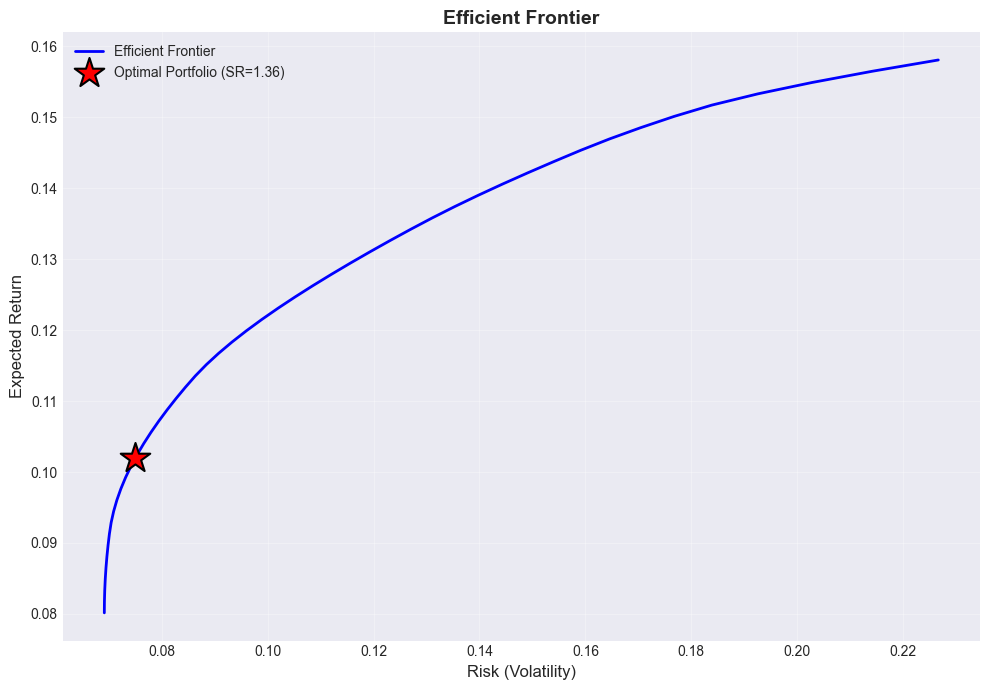

In [10]:
opt.plot_efficient_frontier(show_assets=False)